In [1]:
import os, glob, json
import numpy as np

# OUTDIR = "outputs/outdir_selection_calib_flatmass"  # 改成你的路径
OUTDIR = "outputs/outdir_selection_calib_SEOBNR"  # 改成你的路径
MERGED_NPZ = os.path.join(OUTDIR, "merged_detected.npz")
MERGED_SUMMARY = os.path.join(OUTDIR, "merged_summary.json")

worker_dirs = sorted(glob.glob(os.path.join(OUTDIR, "worker_*")))
assert len(worker_dirs) > 0, f"No worker dirs found under {OUTDIR}"

# ---- read summaries (for total trials, acceptance, etc.) ----
summaries = []
for wd in worker_dirs:
    s1 = os.path.join(wd, "summary.json")
    s2 = os.path.join(wd, "summary_partial.json")
    s3 = os.path.join(wd, "summary_partial.json")  # if you used that name
    if os.path.exists(s1):
        with open(s1, "r", encoding="utf-8") as f:
            summaries.append(json.load(f))
    elif os.path.exists(s2):
        with open(s2, "r", encoding="utf-8") as f:
            summaries.append(json.load(f))
    elif os.path.exists(s3):
        with open(s3, "r", encoding="utf-8") as f:
            summaries.append(json.load(f))

n_workers_found = len(worker_dirs)
n_summ_found = len(summaries)

# ---- load all detected chunks ----
chunk_paths = sorted(glob.glob(os.path.join(OUTDIR, "worker_*", "detected_chunk*.npz")))
assert len(chunk_paths) > 0, f"No detected_chunk*.npz found under {OUTDIR}/worker_*"

# determine keys from first chunk
with np.load(chunk_paths[0], allow_pickle=False) as d:  # safer loading :contentReference[oaicite:2]{index=2}
    keys = list(d.files)

accum = {k: [] for k in keys}
total_rows = 0

for p in chunk_paths:
    with np.load(p, allow_pickle=False) as d:
        n = len(d[keys[0]])
        total_rows += n
        for k in keys:
            accum[k].append(np.asarray(d[k]))

merged = {k: np.concatenate(v) if len(v) else np.array([]) for k, v in accum.items()}

# ---- totals from summaries ----
tot_trials = int(np.sum([s.get("n_trials_total", 0) for s in summaries])) if summaries else None
tot_det = int(np.sum([s.get("n_detected", 0) for s in summaries])) if summaries else int(len(merged[keys[0]]))

print(f"Workers: {n_workers_found} (summaries found: {n_summ_found})")
print(f"Detected rows merged from chunks: {total_rows}")
print(f"Detected from summaries sum: {tot_det}")
if tot_trials is not None and tot_trials > 0:
    print(f"Total trials (all workers): {tot_trials}  => acceptance(det/trials) = {tot_det/tot_trials:.5f}")

# ---- save merged files ----
np.savez_compressed(MERGED_NPZ, **merged)  # compressed npz :contentReference[oaicite:3]{index=3}

merged_summary = dict(
    outdir=os.path.abspath(OUTDIR),
    n_workers=n_workers_found,
    n_chunks=len(chunk_paths),
    n_detected=int(len(merged[keys[0]])),
    n_trials_total=tot_trials,
    acceptance=(tot_det/tot_trials) if (tot_trials is not None and tot_trials > 0) else None,
    keys=keys,
)
with open(MERGED_SUMMARY, "w", encoding="utf-8") as f:
    json.dump(merged_summary, f, indent=2, sort_keys=True)

print("Saved:")
print(" ", MERGED_NPZ)
print(" ", MERGED_SUMMARY)

Workers: 64 (summaries found: 64)
Detected rows merged from chunks: 327680
Detected from summaries sum: 327680
Total trials (all workers): 498763  => acceptance(det/trials) = 0.65699
Saved:
  outdir_selection_calib_SEOBNR/merged_detected.npz
  outdir_selection_calib_SEOBNR/merged_summary.json


N_detected = 327680
SNR: min=30.00, median=52.66, max=2977.18
z:   min=0.0049, median=0.2154, max=0.3000
dL:  min=21.9 Mpc, median=1100.1 Mpc, max=1602.5 Mpc
Median relative |dL - dL(z)| / dL(z) = 0.000e+00


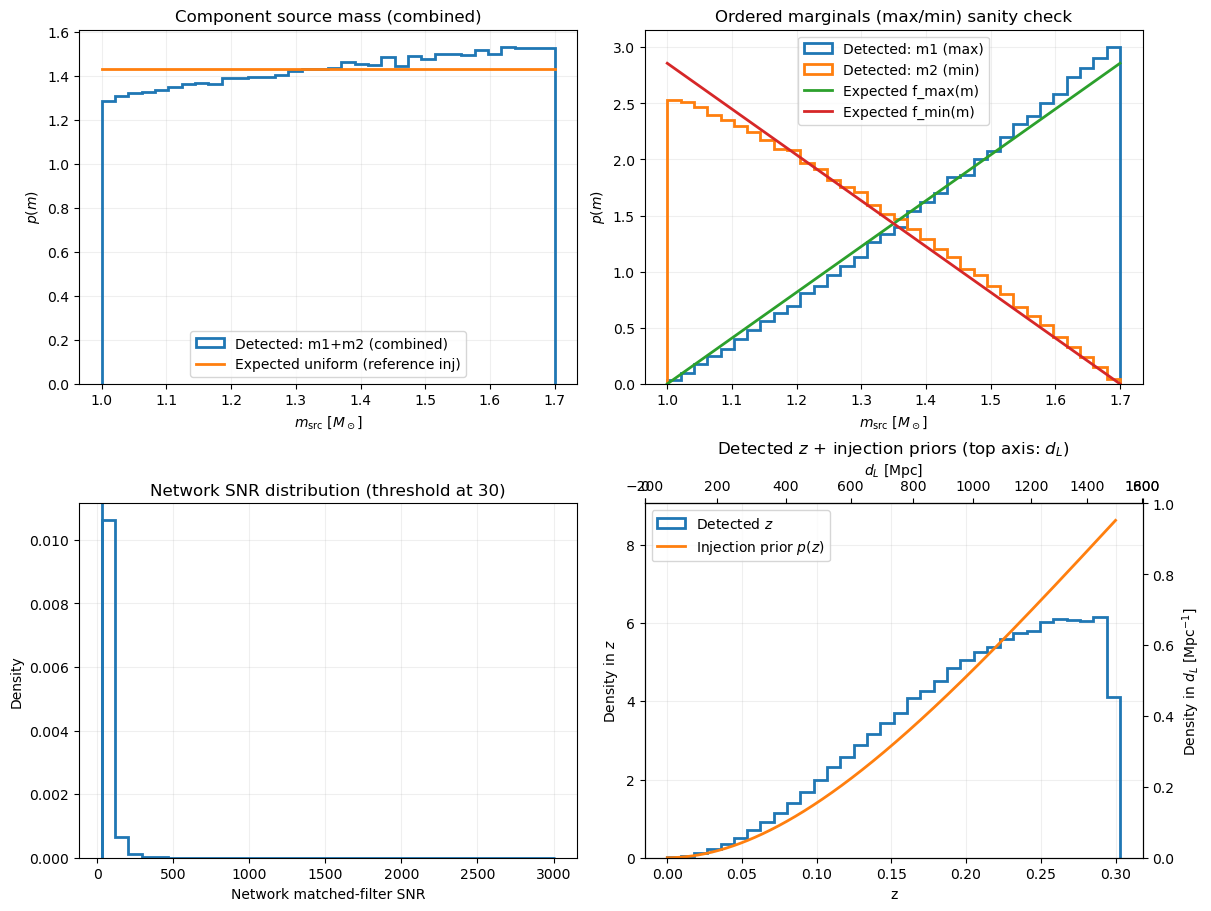

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# load merged
data = np.load(MERGED_NPZ, allow_pickle=False)  # safer loading :contentReference[oaicite:5]{index=5}

m1 = data["m1_src"].astype(float)
m2 = data["m2_src"].astype(float)
mcomp = np.concatenate([m1, m2])  # combined component masses
z = data["z"].astype(float)
dL = data["dL_mpc"].astype(float)
snr = data["network_snr"].astype(float)

print(f"N_detected = {len(m1)}")
print(f"SNR: min={snr.min():.2f}, median={np.median(snr):.2f}, max={snr.max():.2f}")
print(f"z:   min={z.min():.4f}, median={np.median(z):.4f}, max={z.max():.4f}")
print(f"dL:  min={dL.min():.1f} Mpc, median={np.median(dL):.1f} Mpc, max={dL.max():.1f} Mpc")

# infer mass bounds from data (or hardcode your injection bounds)
a = float(min(mcomp.min(), m1.min(), m2.min()))
b = float(max(mcomp.max(), m1.max(), m2.max()))
# if you prefer fixed:
# a, b = 1.0, 1.7

# bins (always cover full range to avoid "missing data" issue) :contentReference[oaicite:6]{index=6}
m_bins = np.linspace(a, b, 35)
snr_bins = np.linspace(30, snr.max()*1.01, 35)
z_bins = np.linspace(0, z.max()*1.01, 35)
dL_bins = np.linspace(0, dL.max()*1.01, 35)

# theoretical marginals for ordered (max/min) if X,Y ~ Uniform[a,b]
# f_max(m) = 2*(m-a)/(b-a)^2 ; f_min(m) = 2*(b-m)/(b-a)^2 ; combined is uniform 1/(b-a)
m_grid = np.linspace(a, b, 400)
f_max = 2*(m_grid - a) / (b - a)**2
f_min = 2*(b - m_grid) / (b - a)**2
f_uni = np.ones_like(m_grid) / (b - a)

# dL(z) consistency spot-check (optional): compare stored dL to Planck18 dL(z)
dL_from_z = Planck18.luminosity_distance(z).value  # Planck18 :contentReference[oaicite:7]{index=7}
rel_err = np.median(np.abs(dL - dL_from_z) / np.maximum(dL_from_z, 1e-9))
print(f"Median relative |dL - dL(z)| / dL(z) = {rel_err:.3e}")

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# (1) combined component mass should be flat
ax = axs[0, 0]
ax.hist(mcomp, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m1+m2 (combined)")
ax.plot(m_grid, f_uni, linewidth=2, label="Expected uniform (reference inj)")
ax.set_xlabel(r"$m_{\rm src}\ [M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Component source mass (combined)")
ax.legend()
ax.grid(alpha=0.2)

# (2) ordered m1 and m2 marginals
ax = axs[0, 1]
ax.hist(m1, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m1 (max)")
ax.hist(m2, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m2 (min)")
ax.plot(m_grid, f_max, linewidth=2, label="Expected f_max(m)")
ax.plot(m_grid, f_min, linewidth=2, label="Expected f_min(m)")
ax.set_xlabel(r"$m_{\rm src}\ [M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Ordered marginals (max/min) sanity check")
ax.legend()
ax.grid(alpha=0.2)

# (3) network SNR (should be >= 30 by construction)
ax = axs[1, 0]
ax.hist(snr, bins=snr_bins, density=True, histtype="step", linewidth=2)
ax.axvline(30.0, linewidth=2)
ax.set_xlabel("Network matched-filter SNR")
ax.set_ylabel("Density")
ax.set_title("Network SNR distribution (threshold at 30)")
ax.grid(alpha=0.2)

# ----------------------------
# (4) Replace this whole block
# ----------------------------

# prior hyper-params (should match your injection config)
Z_MAX_PRIOR = 0.3
GAMMA_PRIOR = 0.0  # p(z) ∝ dVc/dz * (1+z)^(gamma-1)

# Build priors p(z) and p(dL)
z_grid = np.linspace(0.0, Z_MAX_PRIOR, 4000)
dVc_dz = (4.0 * np.pi) * Planck18.differential_comoving_volume(z_grid).value  # Mpc^3 per dz
p_z_unnorm = dVc_dz * (1.0 + z_grid) ** (GAMMA_PRIOR - 1.0)
p_z = p_z_unnorm / np.trapezoid(p_z_unnorm, z_grid)

dL_grid = Planck18.luminosity_distance(z_grid).value  # Mpc
ddL_dz = np.gradient(dL_grid, z_grid)
p_dL_unnorm = p_z / np.abs(ddL_dz)
p_dL = p_dL_unnorm / np.trapezoid(p_dL_unnorm, dL_grid)  # normalize over dL

# mapping functions for secondary x-axis
def z_to_dL(z_in):
    return Planck18.luminosity_distance(np.asarray(z_in)).value

def dL_to_z(dL_in):
    # invert dL(z) via interpolation (monotonic for z>=0)
    return np.interp(np.asarray(dL_in), dL_grid, z_grid)

# ---- right-bottom panel ----
ax = axs[1, 1]

# z histogram (detected)
z_bins = np.linspace(0.0, max(Z_MAX_PRIOR, z.max()) * 1.01, 35)
ax.hist(z, bins=z_bins, density=True, histtype="step", linewidth=2, label="Detected $z$")

# overlay prior p(z)
ax.plot(z_grid, p_z, linewidth=2, label="Injection prior $p(z)$")

ax.set_xlabel("z")
ax.set_ylabel("Density in $z$")
ax.set_title("Detected $z$ + injection priors (top axis: $d_L$)")
ax.grid(alpha=0.2)

# top x-axis shows dL corresponding to z (secondary axis)
secax = ax.secondary_xaxis("top", functions=(z_to_dL, dL_to_z))
secax.set_xlabel(r"$d_L\ [\mathrm{Mpc}]$")

# right y-axis: plot p(dL) prior (as a function of z_grid, but units are Mpc^-1)
axr = ax.twinx()  # shares x with ax :contentReference[oaicite:4]{index=4}
axr.set_ylabel(r"Density in $d_L\ [\mathrm{Mpc}^{-1}]$")

# legends: combine left+right
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = axr.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

plt.show()

data.close()

In [7]:
import os, glob, json
import numpy as np

OUTDIRS = [
    "outputs/outdir_selection_calib_flatmass",
    "outputs/outdir_selection_calib_flatmass_run1",
    "outputs/outdir_selection_calib_flatmass_run2",
]

chunk_paths, summary_paths = [], []
for od in OUTDIRS:
    chunk_paths += sorted(glob.glob(os.path.join(od, "worker_*", "detected_chunk*.npz")))
    summary_paths += sorted(glob.glob(os.path.join(od, "worker_*", "summary*.json")))

with np.load(chunk_paths[0], allow_pickle=False) as d:
    keys = d.files

accum = {k: [] for k in keys}
for p in chunk_paths:
    with np.load(p, allow_pickle=False) as d:
        for k in keys:
            accum[k].append(np.asarray(d[k]))
merged = {k: np.concatenate(v) for k, v in accum.items()}

tot_trials = 0
tot_det = 0
for sp in summary_paths:
    try:
        s = json.load(open(sp, "r"))
        tot_trials += int(s.get("n_trials_total", 0))
        tot_det += int(s.get("n_detected", 0))
    except Exception:
        pass

print("Detected:", len(merged[keys[0]]))
print("Trials:", tot_trials, "  acceptance:", (tot_det/tot_trials) if tot_trials else None)

np.savez_compressed("merged_detected_all.npz", **merged)  # 写压缩 npz :contentReference[oaicite:3]{index=3}

Detected: 327680
Trials: 450880   acceptance: 0.7267565649396736


N_detected = 327680
SNR: min=30.00, median=52.65, max=2158.32
z:   min=0.0049, median=0.2155, max=0.3000
dL:  min=21.9 Mpc, median=1100.3 Mpc, max=1602.5 Mpc
Median relative |dL - dL(z)| / dL(z) = 0.000e+00


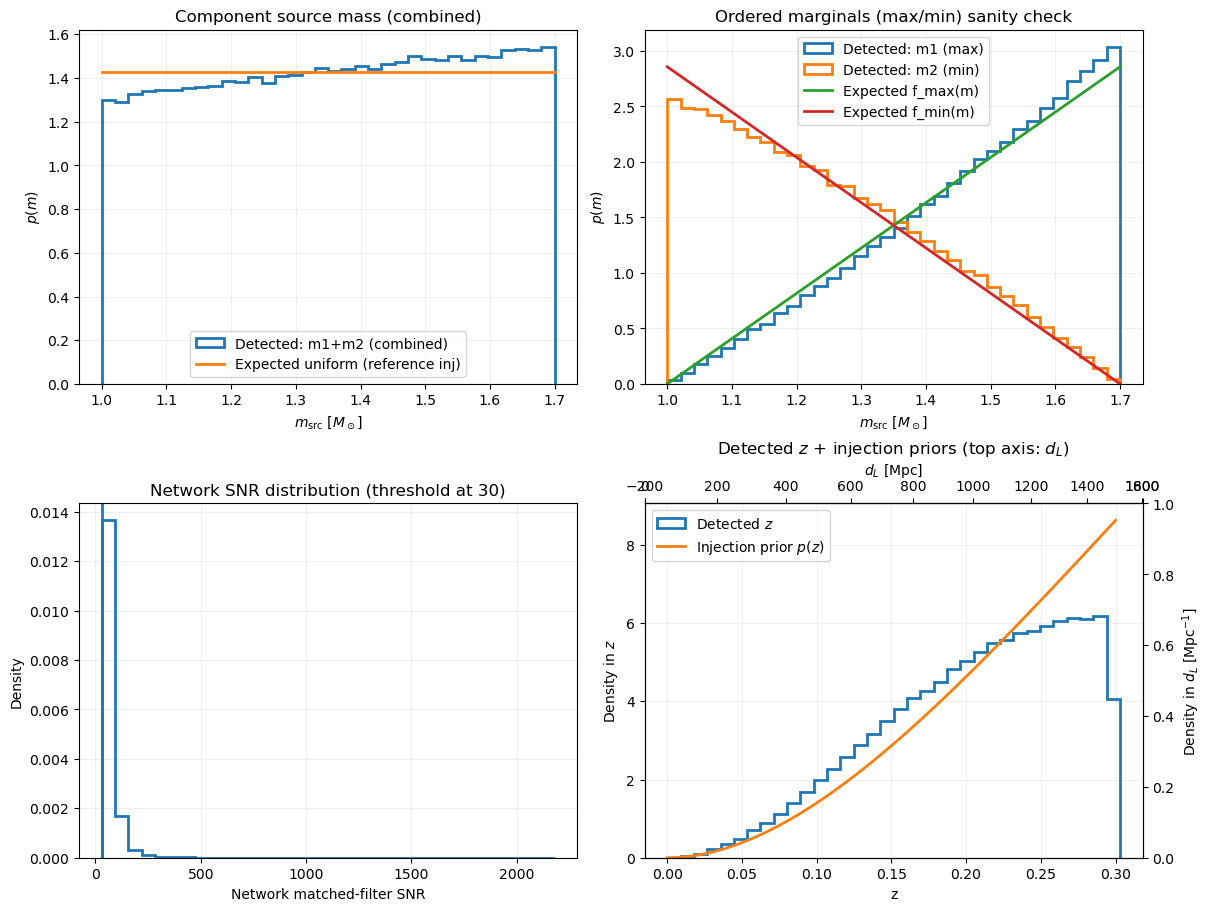

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# load merged
data = np.load("merged_detected_all.npz", allow_pickle=False)  # safer loading :contentReference[oaicite:5]{index=5}

m1 = data["m1_src"].astype(float)
m2 = data["m2_src"].astype(float)
mcomp = np.concatenate([m1, m2])  # combined component masses
z = data["z"].astype(float)
dL = data["dL_mpc"].astype(float)
snr = data["network_snr"].astype(float)

print(f"N_detected = {len(m1)}")
print(f"SNR: min={snr.min():.2f}, median={np.median(snr):.2f}, max={snr.max():.2f}")
print(f"z:   min={z.min():.4f}, median={np.median(z):.4f}, max={z.max():.4f}")
print(f"dL:  min={dL.min():.1f} Mpc, median={np.median(dL):.1f} Mpc, max={dL.max():.1f} Mpc")

# infer mass bounds from data (or hardcode your injection bounds)
a = float(min(mcomp.min(), m1.min(), m2.min()))
b = float(max(mcomp.max(), m1.max(), m2.max()))
# if you prefer fixed:
# a, b = 1.0, 1.7

# bins (always cover full range to avoid "missing data" issue) :contentReference[oaicite:6]{index=6}
m_bins = np.linspace(a, b, 35)
snr_bins = np.linspace(30, snr.max()*1.01, 35)
z_bins = np.linspace(0, z.max()*1.01, 35)
dL_bins = np.linspace(0, dL.max()*1.01, 35)

# theoretical marginals for ordered (max/min) if X,Y ~ Uniform[a,b]
# f_max(m) = 2*(m-a)/(b-a)^2 ; f_min(m) = 2*(b-m)/(b-a)^2 ; combined is uniform 1/(b-a)
m_grid = np.linspace(a, b, 400)
f_max = 2*(m_grid - a) / (b - a)**2
f_min = 2*(b - m_grid) / (b - a)**2
f_uni = np.ones_like(m_grid) / (b - a)

# dL(z) consistency spot-check (optional): compare stored dL to Planck18 dL(z)
dL_from_z = Planck18.luminosity_distance(z).value  # Planck18 :contentReference[oaicite:7]{index=7}
rel_err = np.median(np.abs(dL - dL_from_z) / np.maximum(dL_from_z, 1e-9))
print(f"Median relative |dL - dL(z)| / dL(z) = {rel_err:.3e}")

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# (1) combined component mass should be flat
ax = axs[0, 0]
ax.hist(mcomp, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m1+m2 (combined)")
ax.plot(m_grid, f_uni, linewidth=2, label="Expected uniform (reference inj)")
ax.set_xlabel(r"$m_{\rm src}\ [M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Component source mass (combined)")
ax.legend()
ax.grid(alpha=0.2)

# (2) ordered m1 and m2 marginals
ax = axs[0, 1]
ax.hist(m1, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m1 (max)")
ax.hist(m2, bins=m_bins, density=True, histtype="step", linewidth=2, label="Detected: m2 (min)")
ax.plot(m_grid, f_max, linewidth=2, label="Expected f_max(m)")
ax.plot(m_grid, f_min, linewidth=2, label="Expected f_min(m)")
ax.set_xlabel(r"$m_{\rm src}\ [M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Ordered marginals (max/min) sanity check")
ax.legend()
ax.grid(alpha=0.2)

# (3) network SNR (should be >= 30 by construction)
ax = axs[1, 0]
ax.hist(snr, bins=snr_bins, density=True, histtype="step", linewidth=2)
ax.axvline(30.0, linewidth=2)
ax.set_xlabel("Network matched-filter SNR")
ax.set_ylabel("Density")
ax.set_title("Network SNR distribution (threshold at 30)")
ax.grid(alpha=0.2)

# ----------------------------
# (4) Replace this whole block
# ----------------------------

# prior hyper-params (should match your injection config)
Z_MAX_PRIOR = 0.3
GAMMA_PRIOR = 0.0  # p(z) ∝ dVc/dz * (1+z)^(gamma-1)

# Build priors p(z) and p(dL)
z_grid = np.linspace(0.0, Z_MAX_PRIOR, 4000)
dVc_dz = (4.0 * np.pi) * Planck18.differential_comoving_volume(z_grid).value  # Mpc^3 per dz
p_z_unnorm = dVc_dz * (1.0 + z_grid) ** (GAMMA_PRIOR - 1.0)
p_z = p_z_unnorm / np.trapezoid(p_z_unnorm, z_grid)

dL_grid = Planck18.luminosity_distance(z_grid).value  # Mpc
ddL_dz = np.gradient(dL_grid, z_grid)
p_dL_unnorm = p_z / np.abs(ddL_dz)
p_dL = p_dL_unnorm / np.trapezoid(p_dL_unnorm, dL_grid)  # normalize over dL

# mapping functions for secondary x-axis
def z_to_dL(z_in):
    return Planck18.luminosity_distance(np.asarray(z_in)).value

def dL_to_z(dL_in):
    # invert dL(z) via interpolation (monotonic for z>=0)
    return np.interp(np.asarray(dL_in), dL_grid, z_grid)

# ---- right-bottom panel ----
ax = axs[1, 1]

# z histogram (detected)
z_bins = np.linspace(0.0, max(Z_MAX_PRIOR, z.max()) * 1.01, 35)
ax.hist(z, bins=z_bins, density=True, histtype="step", linewidth=2, label="Detected $z$")

# overlay prior p(z)
ax.plot(z_grid, p_z, linewidth=2, label="Injection prior $p(z)$")

ax.set_xlabel("z")
ax.set_ylabel("Density in $z$")
ax.set_title("Detected $z$ + injection priors (top axis: $d_L$)")
ax.grid(alpha=0.2)

# top x-axis shows dL corresponding to z (secondary axis)
secax = ax.secondary_xaxis("top", functions=(z_to_dL, dL_to_z))
secax.set_xlabel(r"$d_L\ [\mathrm{Mpc}]$")

# right y-axis: plot p(dL) prior (as a function of z_grid, but units are Mpc^-1)
axr = ax.twinx()  # shares x with ax :contentReference[oaicite:4]{index=4}
axr.set_ylabel(r"Density in $d_L\ [\mathrm{Mpc}^{-1}]$")

# legends: combine left+right
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = axr.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

plt.show()

data.close()